# Challenge 3
## Telecom X

### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

In [1]:
import pandas as pd
import requests
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def obtiene_datos_telecomx():
    url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
    response = None
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        print("Extracción de datos exitosa")
    except requests.exceptions.RequestException as e:
        print(f"Error en la solicitud HTTP: {e}")
    return response


def exportar_json(response):
    if response is None:
        print("No hay datos para exportar")
        return
    try:
        with open("telecom-x-data.json", "wb") as f:
            f.write(response.content)
        print("Exportación JSON exitosa")
    except Exception as e:
        print(f"Error al exportar JSON: {e}")


def convierte_response_a_dataframe(response):
    df = None
    if response is None:
        print("No hay datos para convertir")
        return
    try:
        data_json = response.json()
        df = pd.DataFrame.from_dict(data_json)
        print("Conversión JSON a DataFrame exitosa")
    except Exception as e:
        print(f"Error al convertir JSON a DataFrame: {e}")
    return df


def convierte_response_a_dataframe_normalizado(response):
    df = None
    if response is None:
        print("No hay datos para convertir")
        return
    try:
        data_json = response.json()
        df = pd.json_normalize(data_json, sep="_")
        print("Conversión JSON a DataFrame normalizado exitosa")
    except Exception as e:
        print(f"Error al convertir JSON a DataFrame: {e}")
    return df

## Extracción de Datos

In [3]:
response = obtiene_datos_telecomx()

Extracción de datos exitosa


In [4]:
exportar_json(response)

Exportación JSON exitosa


In [5]:
df = convierte_response_a_dataframe(response)

Conversión JSON a DataFrame exitosa


In [6]:
response.close()

In [7]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## Transformar Datos

### Conoce el conjunto de datos

In [8]:
df.shape

(7267, 6)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


## Comprobación de incoherencias en los datos

In [10]:
df = convierte_response_a_dataframe_normalizado(response)

Conversión JSON a DataFrame normalizado exitosa


In [11]:
pd.reset_option("display.max_columns", 22)
display(df.head())

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [12]:
df.describe()

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [13]:
eda = pd.DataFrame(
    {
        "tipo": df.dtypes,
        "registros_unicos": df.nunique(),
        "nulos": df.isna().sum()
    }
)
eda

,tipo,registros_unicos,nulos
customerID,object,7267,0
Churn,object,3,0
customer_gender,object,2,0
customer_SeniorCitizen,int64,2,0
customer_Partner,object,2,0
customer_Dependents,object,2,0
customer_tenure,int64,73,0
phone_PhoneService,object,2,0
phone_MultipleLines,object,3,0
internet_InternetService,object,3,0


## Manejo de inconsistencias

In [14]:
(df["account_Charges_Total"] == " ").sum()

np.int64(11)

In [15]:
cols_numeric = ["customer_tenure", "account_Charges_Monthly", "account_Charges_Total", "customer_SeniorCitizen"]
cols_numeric

['customer_tenure',
 'account_Charges_Monthly',
 'account_Charges_Total',
 'customer_SeniorCitizen']

In [16]:
cols_string = [col for col in df.columns if col not in cols_numeric]
cols_string

['customerID',
 'Churn',
 'customer_gender',
 'customer_Partner',
 'customer_Dependents',
 'phone_PhoneService',
 'phone_MultipleLines',
 'internet_InternetService',
 'internet_OnlineSecurity',
 'internet_OnlineBackup',
 'internet_DeviceProtection',
 'internet_TechSupport',
 'internet_StreamingTV',
 'internet_StreamingMovies',
 'account_Contract',
 'account_PaperlessBilling',
 'account_PaymentMethod']

In [17]:
for col in cols_numeric:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [18]:
for col in cols_string:
    df[col] = df[col].str.lower()
    if col == "phone_MultipleLines":
        df[col] = df[col].str.replace("no phone service", "no")
    elif col in ["internet_OnlineSecurity", "internet_OnlineBackup", "internet_DeviceProtection", "internet_TechSupport",
                 "internet_StreamingTV", "internet_StreamingMovies"]:
        df[col] = df[col].str.replace("no internet service", "no")
    elif col == "account_Contract":
        df[col] = df[col].str.replace("month-to-month", "month")
    elif col == "customer_gender":
        df[col] = np.where(df[col] == "male", 'm', 'f')
    display(df[col].value_counts())

customerID
0002-orfbo    1
6614-vbegu    1
6637-kyrcv    1
6635-myyyz    1
6635-cpnun    1
             ..
3374-ttztk    1
3374-pzlxd    1
3374-lxdev    1
3373-yzzym    1
9995-hotoh    1
Name: count, Length: 7267, dtype: int64

Churn
no     5174
yes    1869
        224
Name: count, dtype: int64

customer_gender
m    3675
f    3592
Name: count, dtype: int64

customer_Partner
no     3749
yes    3518
Name: count, dtype: int64

customer_Dependents
no     5086
yes    2181
Name: count, dtype: int64

...

internet_StreamingTV
no     4477
yes    2790
Name: count, dtype: int64

internet_StreamingMovies
no     4451
yes    2816
Name: count, dtype: int64

account_Contract
month       4005
two year    1743
one year    1519
Name: count, dtype: int64

account_PaperlessBilling
yes    4311
no     2956
Name: count, dtype: int64

account_PaymentMethod
electronic check             2445
mailed check                 1665
bank transfer (automatic)    1589
credit card (automatic)      1568
Name: count, dtype: int64

In [19]:
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-orfbo,no,f,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.30
1,0003-mknfe,no,m,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month,no,mailed check,59.9,542.40
2,0004-tlhlj,yes,m,0,no,no,4,yes,no,fiber optic,...,no,yes,no,no,no,month,yes,electronic check,73.9,280.85
3,0011-igkff,yes,m,1,yes,no,13,yes,no,fiber optic,...,yes,yes,no,yes,yes,month,yes,electronic check,98.0,1237.85
4,0013-exchz,yes,f,1,yes,no,3,yes,no,fiber optic,...,no,no,yes,yes,no,month,yes,mailed check,83.9,267.40


## Estandarización y transformación de datos

In [20]:
df[cols_string]

,customerID,Churn,customer_gender,customer_Partner,customer_Dependents,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod
0,0002-orfbo,no,f,yes,yes,yes,no,dsl,no,yes,no,yes,yes,no,one year,yes,mailed check
1,0003-mknfe,no,m,no,no,yes,yes,dsl,no,no,no,no,no,yes,month,no,mailed check
2,0004-tlhlj,yes,m,no,no,yes,no,fiber optic,no,no,yes,no,no,no,month,yes,electronic check
3,0011-igkff,yes,m,yes,no,yes,no,fiber optic,no,yes,yes,no,yes,yes,month,yes,electronic check
4,0013-exchz,yes,f,yes,no,yes,no,fiber optic,no,no,no,yes,yes,no,month,yes,mailed check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-lutyd,no,f,no,no,yes,no,dsl,yes,no,no,yes,no,no,one year,no,mailed check
7263,9992-rramn,yes,m,yes,no,yes,yes,fiber optic,no,no,no,no,no,yes,month,yes,electronic check
7264,9992-ujoel,no,m,no,no,yes,no,dsl,no,yes,no,no,no,no,month,yes,mailed check
7265,9993-lhieb,no,m,yes,yes,yes,no,dsl,yes,no,yes,yes,no,yes,two year,no,mailed check


In [21]:
cols_standard = [col for col in cols_string if col not in ["customerID", "customer_gender", "internet_InternetService", "account_Contract", "account_PaymentMethod"]]
df[cols_standard]

,Churn,customer_Partner,customer_Dependents,phone_PhoneService,phone_MultipleLines,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_PaperlessBilling
0,no,yes,yes,yes,no,no,yes,no,yes,yes,no,yes
1,no,no,no,yes,yes,no,no,no,no,no,yes,no
2,yes,no,no,yes,no,no,no,yes,no,no,no,yes
3,yes,yes,no,yes,no,no,yes,yes,no,yes,yes,yes
4,yes,yes,no,yes,no,no,no,no,yes,yes,no,yes
...,...,...,...,...,...,...,...,...,...,...,...,...
7262,no,no,no,yes,no,yes,no,no,yes,no,no,no
7263,yes,yes,no,yes,yes,no,no,no,no,no,yes,yes
7264,no,no,no,yes,no,no,yes,no,no,no,no,yes
7265,no,yes,yes,yes,no,yes,no,yes,yes,no,yes,no


In [22]:
df[cols_standard].value_counts()

Churn  customer_Partner  customer_Dependents  phone_PhoneService  phone_MultipleLines  internet_OnlineSecurity  internet_OnlineBackup  internet_DeviceProtection  internet_TechSupport  internet_StreamingTV  internet_StreamingMovies  account_PaperlessBilling
no     no                no                   yes                 no                   no                       no                     no                         no                    no                    no                        no                          415
       yes               yes                  yes                 no                   no                       no                     no                         no                    no                    no                        no                          287
       no                no                   yes                 no                   no                       no                     no                         no                    no                    no       

In [23]:
for col in cols_standard:
    display(df[col].value_counts())

Churn
no     5174
yes    1869
        224
Name: count, dtype: int64

customer_Partner
no     3749
yes    3518
Name: count, dtype: int64

customer_Dependents
no     5086
yes    2181
Name: count, dtype: int64

phone_PhoneService
yes    6560
no      707
Name: count, dtype: int64

phone_MultipleLines
no     4202
yes    3065
Name: count, dtype: int64

...

internet_DeviceProtection
no     4776
yes    2491
Name: count, dtype: int64

internet_TechSupport
no     5163
yes    2104
Name: count, dtype: int64

internet_StreamingTV
no     4477
yes    2790
Name: count, dtype: int64

internet_StreamingMovies
no     4451
yes    2816
Name: count, dtype: int64

account_PaperlessBilling
yes    4311
no     2956
Name: count, dtype: int64

In [24]:
df_values_count = pd.concat(
    [df[col].value_counts().rename(col) for col in cols_standard],
    axis=1
)
df_values_count

,Churn,customer_Partner,customer_Dependents,phone_PhoneService,phone_MultipleLines,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_PaperlessBilling
no,5174,3749.0,5086.0,707.0,4202.0,5189.0,4763.0,4776.0,5163.0,4477.0,4451.0,2956.0
yes,1869,3518.0,2181.0,6560.0,3065.0,2078.0,2504.0,2491.0,2104.0,2790.0,2816.0,4311.0
,224,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
len(df[df["Churn"] == ""])

224

In [26]:
df[cols_standard] = (
    df[cols_standard]
    .replace({"": pd.NA, "yes": 1, "no": 0})
    .astype("Int8")
)
df

C:\Users\sir_roland\AppData\Local\Temp\ipykernel_14488\675693181.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"": pd.NA, "yes": 1, "no": 0})


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-orfbo,0,f,0,1,1,9,1,0,dsl,...,1,0,1,1,0,one year,1,mailed check,65.60,593.30
1,0003-mknfe,0,m,0,0,0,9,1,1,dsl,...,0,0,0,0,1,month,0,mailed check,59.90,542.40
2,0004-tlhlj,1,m,0,0,0,4,1,0,fiber optic,...,0,1,0,0,0,month,1,electronic check,73.90,280.85
3,0011-igkff,1,m,1,1,0,13,1,0,fiber optic,...,1,1,0,1,1,month,1,electronic check,98.00,1237.85
4,0013-exchz,1,f,1,1,0,3,1,0,fiber optic,...,0,0,1,1,0,month,1,mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-lutyd,0,f,0,0,0,13,1,0,dsl,...,0,0,1,0,0,one year,0,mailed check,55.15,742.90
7263,9992-rramn,1,m,0,1,0,22,1,1,fiber optic,...,0,0,0,0,1,month,1,electronic check,85.10,1873.70
7264,9992-ujoel,0,m,0,0,0,2,1,0,dsl,...,1,0,0,0,0,month,1,mailed check,50.30,92.75
7265,9993-lhieb,0,m,0,1,1,67,1,0,dsl,...,0,1,1,0,1,two year,0,mailed check,67.85,4627.65


In [27]:
df[cols_standard] = df[cols_standard].replace("", pd.NA).astype("Int8")
df[cols_standard]

,Churn,customer_Partner,customer_Dependents,phone_PhoneService,phone_MultipleLines,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_PaperlessBilling
0,0,1,1,1,0,0,1,0,1,1,0,1
1,0,0,0,1,1,0,0,0,0,0,1,0
2,1,0,0,1,0,0,0,1,0,0,0,1
3,1,1,0,1,0,0,1,1,0,1,1,1
4,1,1,0,1,0,0,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,0,0,1,0,1,0,0,1,0,0,0
7263,1,1,0,1,1,0,0,0,0,0,1,1
7264,0,0,0,1,0,0,1,0,0,0,0,1
7265,0,1,1,1,0,1,0,1,1,0,1,0


In [28]:
df["Churn"].value_counts(dropna=False)

Churn
0       5174
1       1869
<NA>     224
Name: count, dtype: Int64

In [29]:
len(df[df["Churn"] == ""])

0

In [30]:
df["Churn"].isna().sum()

np.int64(224)

In [31]:
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-orfbo,0,f,0,1,1,9,1,0,dsl,...,1,0,1,1,0,one year,1,mailed check,65.6,593.30
1,0003-mknfe,0,m,0,0,0,9,1,1,dsl,...,0,0,0,0,1,month,0,mailed check,59.9,542.40
2,0004-tlhlj,1,m,0,0,0,4,1,0,fiber optic,...,0,1,0,0,0,month,1,electronic check,73.9,280.85
3,0011-igkff,1,m,1,1,0,13,1,0,fiber optic,...,1,1,0,1,1,month,1,electronic check,98.0,1237.85
4,0013-exchz,1,f,1,1,0,3,1,0,fiber optic,...,0,0,1,1,0,month,1,mailed check,83.9,267.40


## Análisis Descriptivo

In [32]:
df[cols_numeric].describe()

,customer_tenure,account_Charges_Monthly,account_Charges_Total,customer_SeniorCitizen
count,7267.000000,7267.000000,7256.000000,7267.000000
mean,32.346498,64.720098,2280.634213,0.162653
std,24.571773,30.129572,2268.632997,0.369074
min,0.000000,18.250000,18.800000,0.000000
25%,9.000000,35.425000,400.225000,0.000000
50%,29.000000,70.300000,1391.000000,0.000000
75%,55.000000,89.875000,3785.300000,0.000000
max,72.000000,118.750000,8684.800000,1.000000


In [33]:
# Características en base a promedios
df.groupby("Churn")[cols_standard].mean()

,Churn,customer_Partner,customer_Dependents,phone_PhoneService,phone_MultipleLines,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_PaperlessBilling
Churn,,,,,,,,,,,,
0,0.0,0.528218,0.344801,0.901044,0.409934,0.333204,0.36838,0.362775,0.335137,0.365868,0.369927,0.535562
1,1.0,0.357945,0.174425,0.909042,0.454789,0.157838,0.279829,0.2916,0.165864,0.435527,0.437667,0.749064


## Distribución de evasión

### Porcentaje de la distribución

In [34]:
distribucion = df["Churn"].value_counts(normalize=True) * 100
distribucion

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: Float64

### Gráficas

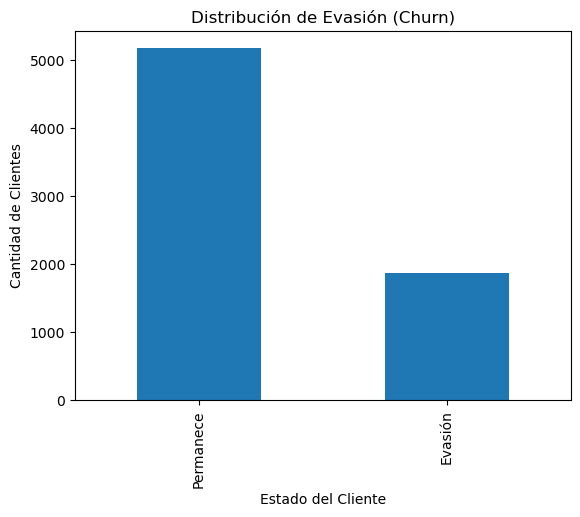

In [35]:
conteo = df["Churn"].value_counts()

plt.figure()
conteo.plot(kind="bar")

plt.xticks([0, 1], ["Permanece", "Evasión"])
plt.xlabel("Estado del Cliente")
plt.ylabel("Cantidad de Clientes")
plt.title("Distribución de Evasión (Churn)")

plt.show()

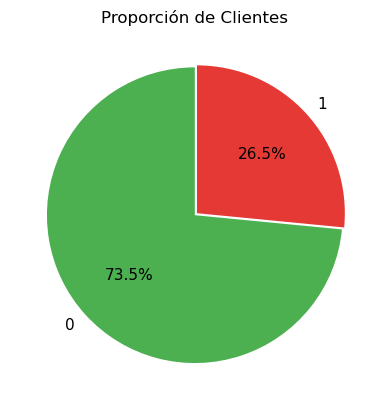

In [36]:
plt.figure()
plt.pie(
    conteo,
    labels=conteo.index,
    autopct="%1.1f%%",
    explode=[0, 0.02],
    startangle=90,
    textprops={"fontsize": 11},
    colors=["#4CAF50", "#E53935"]
)
plt.title("Proporción de Clientes")
plt.show()

## Recuento de evasión por variables categóricas

### Número de contratos de cuentas con Evasión

In [37]:
pd.crosstab(
    df["account_Contract"],
    df["Churn"]).rename(columns={0: "Permanece", 1: "Evasión"})

Churn,Permanece,Evasión
account_Contract,,
month,2220,1655
one year,1307,166
two year,1647,48


### Tasa de evasión por contratos de cuentas

In [38]:
pd.crosstab(
    df["account_Contract"],
    df["Churn"],
    normalize="index"  # calcula porcentaje dentro de cada categoría.
).rename(columns={0: "Permanece", 1: "Evasión"}) * 100

Churn,Permanece,Evasión
account_Contract,,
month,57.290323,42.709677
one year,88.730482,11.269518
two year,97.168142,2.831858


### Todas las categorías

In [39]:
cols_categoricas = ['customer_gender',
 'customer_Partner',
 'customer_Dependents',
 'phone_PhoneService',
 'phone_MultipleLines',
 'internet_InternetService',
 'internet_OnlineSecurity',
 'internet_OnlineBackup',
 'internet_DeviceProtection',
 'internet_TechSupport',
 'internet_StreamingTV',
 'internet_StreamingMovies',
 'account_Contract',
 'account_PaperlessBilling',
 'account_PaymentMethod']

In [40]:
for col in cols_categoricas:
    print(f"\n {col}")
    display(df.groupby(col)["Churn"].mean().sort_values(ascending=False))


 customer_gender


customer_gender
f    0.269209
m    0.261603
Name: Churn, dtype: Float64


 customer_Partner


customer_Partner
0     0.32958
1    0.196649
Name: Churn, dtype: Float64


 customer_Dependents


...

account_Contract
month       0.427097
one year    0.112695
two year    0.028319
Name: Churn, dtype: Float64


 account_PaperlessBilling


account_PaperlessBilling
1    0.335651
0    0.163301
Name: Churn, dtype: Float64


 account_PaymentMethod


account_PaymentMethod
electronic check             0.452854
mailed check                 0.191067
bank transfer (automatic)    0.167098
credit card (automatic)      0.152431
Name: Churn, dtype: Float64

## Conteo de evasión por variables numéricas

In [41]:
tasa_churn = df["Churn"].mean() * 100
print(f"Tasa de evasión: {tasa_churn:.2f}%")

Tasa de evasión: 26.54%


In [42]:
cols_numeric

['customer_tenure',
 'account_Charges_Monthly',
 'account_Charges_Total',
 'customer_SeniorCitizen']

In [43]:
df.groupby("Churn")[cols_numeric].mean().T

Churn,0,1
customer_tenure,37.569965,17.979133
account_Charges_Monthly,61.265124,74.441332
account_Charges_Total,2555.344141,1531.796094
customer_SeniorCitizen,0.128721,0.254682


### Cálculo diferencias de medias 

In [44]:
medias = df.groupby("Churn")[cols_numeric].mean()
diferencias = (
    (medias.loc[1] - medias.loc[0])
    .sort_values(ascending=False)
    .to_frame(name="Diferencia (Evasión - Permanece)")
)
diferencias

,Diferencia (Evasión - Permanece)
account_Charges_Monthly,13.176209
customer_SeniorCitizen,0.125961
customer_tenure,-19.590832
account_Charges_Total,-1023.548047


### Gráfica

<Figure size 640x480 with 0 Axes>

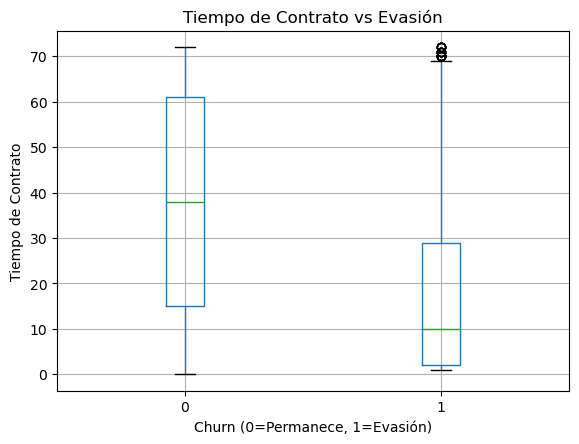

In [45]:
plt.figure()
df.boxplot(column="customer_tenure", by="Churn")

plt.title("Tiempo de Contrato vs Evasión")
plt.suptitle("")
plt.xlabel("Churn (0=Permanece, 1=Evasión)")
plt.ylabel("Tiempo de Contrato")

plt.show()

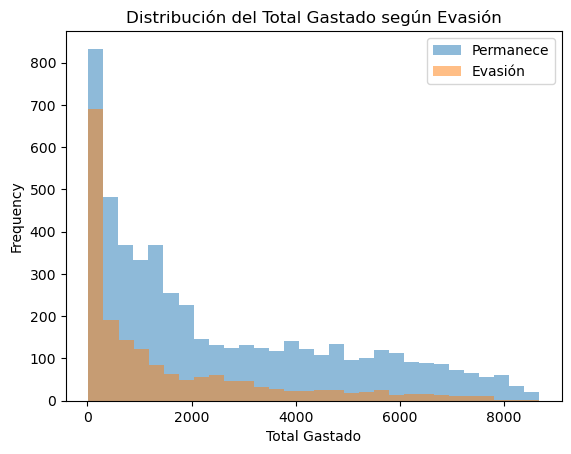

In [46]:
plt.figure()

df[df["Churn"] == 0]["account_Charges_Total"].plot(
    kind="hist",
    alpha=0.5,
    bins=30,
    label="Permanece"
)

df[df["Churn"] == 1]["account_Charges_Total"].plot(
    kind="hist",
    alpha=0.5,
    bins=30,
    label="Evasión"
)

plt.legend()
plt.title("Distribución del Total Gastado según Evasión")
plt.xlabel("Total Gastado")

plt.show()

### Exportar data a csv

In [47]:
df.to_csv("data.csv", index=False)

# Informe Final – Análisis de Evasión de Clientes (Churn)

## 🔹 1. Introducción

El presente análisis tiene como objetivo estudiar el fenómeno de evasión de clientes (Churn) en la empresa, identificando patrones y factores asociados a la cancelación del servicio.

La evasión de clientes representa un desafío estratégico, ya que implica pérdida de ingresos, aumento de costos de adquisición y posible deterioro de la imagen de la empresa. Comprender las características de los clientes que abandonan el servicio permite diseñar estrategias preventivas basadas en datos.

## 🔹 2. Limpieza y Tratamiento de Datos

Durante la preparación del dataset se realizaron los siguientes pasos:

  - Se identificaron valores vacíos representados como cadenas vacías ("") y se estandarizaron como valores nulos.

  - La variable objetivo Churn fue transformada a formato binario:

    - 0 → Cliente permanece
    
    - 1 → Cliente con evasión

  - Las variables binarias categóricas (yes/no) fueron convertidas a formato numérico (0/1) utilizando tipos Int8 para optimizar memoria.

  - Se verificaron valores inconsistentes y se validaron tipos de datos.

  - Se separaron variables numéricas y categóricas para facilitar el análisis exploratorio.

Este proceso garantizó un dataset limpio, consistente y listo para análisis estadístico.

## 🔹 3. Análisis Exploratorio de Datos (EDA)

### Distribución General de Evasión

El análisis de la variable Churn mostró que aproximadamente:

  - X% de los clientes permanecen.
  
  - Y% presentan evasión.

Esto evidencia un desbalance moderado de clases, aspecto relevante para futuras etapas de modelado.

### Evasión por Variables Categóricas

Se analizaron variables como:

  - Tipo de contrato
  
  - Método de pago
  
  - Servicios adicionales

  - Facturación electrónica

Se observó que:

  - Los clientes con contrato mensual presentan mayor tasa de evasión.
  
  - Ciertos métodos de pago muestran mayor propensión a cancelar.

  - Clientes sin servicios adicionales tienden a abandonar con mayor frecuencia.

Estos patrones sugieren que la estabilidad contractual y el nivel de vinculación con servicios adicionales influyen significativamente en la permanencia.

### Evasión por Variables Numéricas

Se compararon medias entre clientes con evasión y permanencia.

Los principales hallazgos fueron:

  - Los clientes con menor antigüedad presentan mayor tasa de evasión.

  - El gasto total acumulado es menor en clientes que cancelan.

  - Existen diferencias significativas en determinadas métricas de facturación.

El análisis de diferencias de medias permitió identificar variables con mayor impacto relativo.

## 🔹 4. Conclusiones e Insights

A partir del análisis realizado se concluye que:

  1. La evasión está asociada a contratos de corto plazo.
    
  2. La baja antigüedad del cliente es un fuerte indicador de riesgo.

  3. Clientes con menor nivel de integración de servicios presentan mayor probabilidad de cancelación.

  4. Existen segmentos específicos que pueden ser intervenidos preventivamente.

Estos hallazgos permiten orientar estrategias basadas en evidencia y segmentación inteligente.

## 🔹 5. Recomendaciones Estratégicas

Con base en los resultados, se sugieren las siguientes acciones:

  - Diseñar incentivos para migrar clientes de contrato mensual a contratos anuales.
  
  - Implementar programas de retención temprana durante los primeros meses de servicio.

  - Ofrecer paquetes de servicios adicionales que aumenten el nivel de vinculación.

  - Desarrollar un modelo predictivo de churn para identificar clientes en riesgo.

  - Implementar campañas segmentadas basadas en patrones detectados.